In [1]:
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
from requests.compat import urljoin
import xarray as xr

from crlx.sikuliaq import SIKULIAQ
from crlx.core import assign_latlon

In [2]:
edt = datetime.now(timezone.utc)
bdt = edt - timedelta(seconds = 3600)

In [3]:
crlx = SIKULIAQ(verbose = True)

In [4]:
sst = crlx.get_sbe38(bdt, edt, request_buffer = 60, max_gap = 3)

In [5]:
sensor_ids = np.unique(sst.sensor_id)
if len(sensor_ids) == 1:
    sensor_id = str(sensor_ids[0])
else:
    print('More than one sensor detected in output. No handling code implemented yet.')

In [6]:
url = urljoin(crlx.VESSEL.API_URL, 'sensor')
params = {'sensor_id': sensor_id, 'enabled': True}
response = requests.get(url, params = params)
data = response.json()
df = pd.DataFrame(data)
sensor_info = df.to_xarray()

In [7]:
sensor_info

<xarray.Dataset> Size: 842B
Dimensions:                         (index: 1)
Coordinates:
  * index                           (index) int64 8B 0
Data variables: (12/113)
    sensor_id                       (index) object 8B 'thermo000631'
    sensor_uuid                     (index) object 8B None
    sensor_name                     (index) object 8B 'Temperature SBE 38_0631'
    sensor_class                    (index) object 8B 'Flowthrough'
    sensor_type                     (index) object 8B 'Thermometer, Water'
    sensor_prefix                   (index) object 8B 'thermw'
    ...                              ...
    last_maintenance_date           (index) object 8B None
    cal_recommended_freq_months     (index) int64 8B 24
    last_cal_date                   (index) object 8B '2023-01-31T00:00:00Z'
    cal_due_date                    (index) object 8B '2025-01-31T00:00:00Z'
    replacement_date                (index) object 8B None
    warranty_end_date               (index) object 8B None

Text(0, 0.5, 'Latitude')

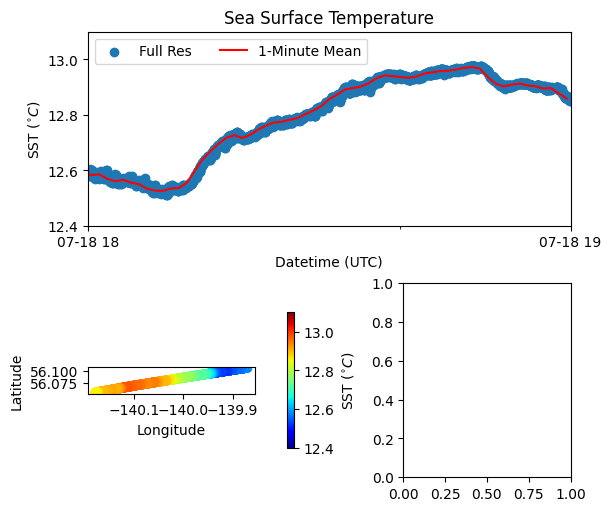

In [8]:
vmin = np.round(sst.sea_surface_temperature.min(),1) - 0.1
vmax = np.round(sst.sea_surface_temperature.max(),1) + 0.1
sstr = sst.sea_surface_temperature.resample({'time': '60s'}).mean()

figsize = (6,5)
fig = plt.figure(figsize = figsize, constrained_layout = True)
grid = (2,2)
ax1 = plt.subplot2grid(grid, (0,0), colspan = 2,rowspan = 1)
ax2 = plt.subplot2grid(grid, (1,0), colspan = 1,rowspan = 1)
ax3 = plt.subplot2grid(grid, (1,1), colspan = 1,rowspan = 1)

ax1.scatter(sst.time, sst.sea_surface_temperature,label = 'Full Res')
ax1.plot(sstr.time, sstr,'red', label = '1-Minute Mean')
ax1.xaxis.set_major_locator(mdates.HourLocator(interval = 6))
ax1.xaxis.set_minor_locator(mdates.HourLocator(interval = 1))
ax1.set_ylim(vmin, vmax)
ax1.legend(loc = 'upper left', ncol = 2)
ax1.set_title('Sea Surface Temperature')
ax1.set_xlabel('Datetime (UTC)')
ax1.set_ylabel(r'SST ($^{\circ}C$)')
ax1.set_xlim(sst.time.min(), sst.time.max())

p2 = ax2.scatter(sst.longitude, sst.latitude, c = sst.sea_surface_temperature, vmin = vmin, vmax = vmax, cmap = 'jet')
fig.colorbar(p2, ax = ax2, label = r'SST ($^{\circ}C$)', pad = -0.15, shrink = 0.7)
ax2.set_box_aspect((sst.latitude.max().values - sst.latitude.min().values)/(sst.longitude.max().values-sst.longitude.min().values))
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')